# Imports

In [3]:
# Linear algebra
import numpy as np

# Dataframes
import pandas as pd

# Path
import os
data_path = os.path.join('..', 'data')
split_dataset_path = os.path.join(data_path, 'Split Dataset')
results_path = os.path.join(data_path, 'Results')

# Plotting
import seaborn as sns
import matplotlib.pyplot as plt

# Translate codons to amino acids
from Bio.Seq import Seq

# Load Data

In [4]:
train_df = pd.read_pickle(os.path.join(split_dataset_path, "0_train_50.pkl"))
validation_df = pd.read_pickle(os.path.join(split_dataset_path, "1_validation_50.pkl"))
test_df = pd.read_pickle(os.path.join(split_dataset_path, "2_test_50.pkl"))

In [ ]:
import json

# Convert lists to JSON strings
train_df["median"] = train_df["median"].apply(json.dumps)
test_df["median"] = test_df["median"].apply(json.dumps)
validation_df["median"] = validation_df["median"].apply(json.dumps)

# Save to CSV
train_df.to_csv(os.path.join(data_path, "0_train_50.json.csv"), index=False)
validation_df.to_csv(os.path.join(data_path, "1_validation_50.json.csv"), index=False)
test_df.to_csv(os.path.join(data_path, "2_test_50.json.csv"), index=False)


# Frequency Based Models

## Harmonizer

### Utils

In [5]:
def get_dna_codons():
  nt_bases = ['A', 'C', 'G', 'T']
  codons = [c1 + c2 + c3 for c1 in nt_bases for c2 in nt_bases for c3 in nt_bases]
  return codons

# Create a dictionary mapping amino acids to all possible codons
def get_amino_acid_codon_dict():
  codons = get_dna_codons()
  
  amino_acid_codon_dict = {}
  for codon in codons:
    aa = str(Seq(codon).translate())
    if aa not in amino_acid_codon_dict:
      amino_acid_codon_dict[aa] = []
    amino_acid_codon_dict[aa].append(codon)
  return amino_acid_codon_dict

### Harmonizer Class

In [6]:
class Harmonizer:

    def __init__(self, train_X, train_Y, verbose=False):
        """Get aa sequences X and codon sequences Y pandas columns.

        Create Frequency Based Model."""
        self.train_X = train_X
        self.train_Y = train_Y

        if verbose:
            print("--- Training Frequency Model ---")

        # Create a DataFrame from the nucleotide and amino acid sequences
        self.train_df = pd.DataFrame({'amino_acids': train_X, 'nucleotides': train_Y})
        
        if verbose:
            print("    * Calculating Codon Fractions...")
        
        self._amino_acid_codon_dict, \
        self._amino_acid_codon_frac_dict = self.calculate_amino_acid_codon_frac_dict()

        if verbose:
            print("    * Finding Most Frequent Codon for each Amino Acid...")
        
        self._amino_acid_most_freq_codon_dict = self.calculate_amino_acid_most_freq_codon_dict()

        if verbose:
            print("--- Training Finished! ---")

    # Create a dictionary mapping amino acids to list of codon frequencies
    def calculate_amino_acid_codon_frac_dict(self):
        amino_acid_codon_dict = get_amino_acid_codon_dict()

        amino_acid_codon_frac_dict = {aa: [0 for _ in amino_acid_codon_dict[aa]] for aa in amino_acid_codon_dict.keys()}

        total_counts = {aa: 0 for aa in amino_acid_codon_dict.keys()}

        for seq, aa_seq in zip(self.train_Y, self.train_X):
            codon_list = [seq[i:i+3] for i in range(0, len(seq), 3)]
            aa_seq = str(Seq(seq).translate())

            for aa, codon in zip(aa_seq, codon_list):
                if codon in amino_acid_codon_dict[aa]:
                    codon_index = amino_acid_codon_dict[aa].index(codon)
                    amino_acid_codon_frac_dict[aa][codon_index] += 1
                    total_counts[aa] += 1

        for aa, codons in amino_acid_codon_frac_dict.items():
            for i in range(len(codons)):
                if total_counts[aa] > 0:
                    amino_acid_codon_frac_dict[aa][i] /= total_counts[aa]

        return amino_acid_codon_dict, amino_acid_codon_frac_dict

    # Create a dictionary mapping amino acids to most frequent codon
    def calculate_amino_acid_most_freq_codon_dict(self):
        amino_acid_most_freq_codon_dict = {}
        for aa, codons in self._amino_acid_codon_frac_dict.items():
            most_freq_index = np.argmax(codons)
            amino_acid_most_freq_codon_dict[aa] = self._amino_acid_codon_dict[aa][most_freq_index]
        return amino_acid_most_freq_codon_dict

    def predict_codons(self, amino_acid_sequences, verbose=False):
        """Predict the codon sequences for a pandas column of amino acid sequences."""
        
        if verbose:
            print("Predicting codons for amino acid sequences...")
            # Vectorized prediction
        def predict_sequence(aa_seq):
            return ''.join(self._amino_acid_most_freq_codon_dict[aa] for aa in aa_seq)

        predicted_codons = amino_acid_sequences.apply(predict_sequence)
        return predicted_codons.tolist()
    
    def calculate_accuracies(self, predictions, ground_truth, verbose=False):
        accuracies = []
        for pred, gt in zip(predictions, ground_truth):
            correct = sum([1 for p, g in zip([pred[i:i+3] for i in range(0, len(pred), 3)], [gt[i:i+3] for i in range(0, len(gt), 3)]) if p == g])
            assert len(gt) % 3 == 0
            total = len(gt) // 3
            accuracies.append(correct / total)
        return accuracies

       

In [ ]:
# Load data
import json

# Load train data from CSV and convert JSON strings back to lists
train_df = pd.read_csv(os.path.join(data_path, "0_train_50.json.csv"))
train_df["median"] = train_df["median"].apply(lambda x: json.loads(x) if isinstance(x, str) else x)

# Load test data from CSV and convert JSON strings back to lists
# test_df = pd.read_csv("2_test_50.json.csv")
# test_df["median"] = test_df["median"].apply(lambda x: json.loads(x) if isinstance(x, str) else x)

### Train and Test Harmoizer

In [7]:
# Example inputs for training
nt_sequences = train_df['seq']
aa_sequences = train_df['amino_acid_seq']

# Create an instance of Frequency_Model
harmonizer_model = Harmonizer(aa_sequences, nt_sequences, verbose=True)


--- Training Frequency Model ---
    * Calculating Codon Fractions...
    * Finding Most Frequent Codon for each Amino Acid...
--- Training Finished! ---


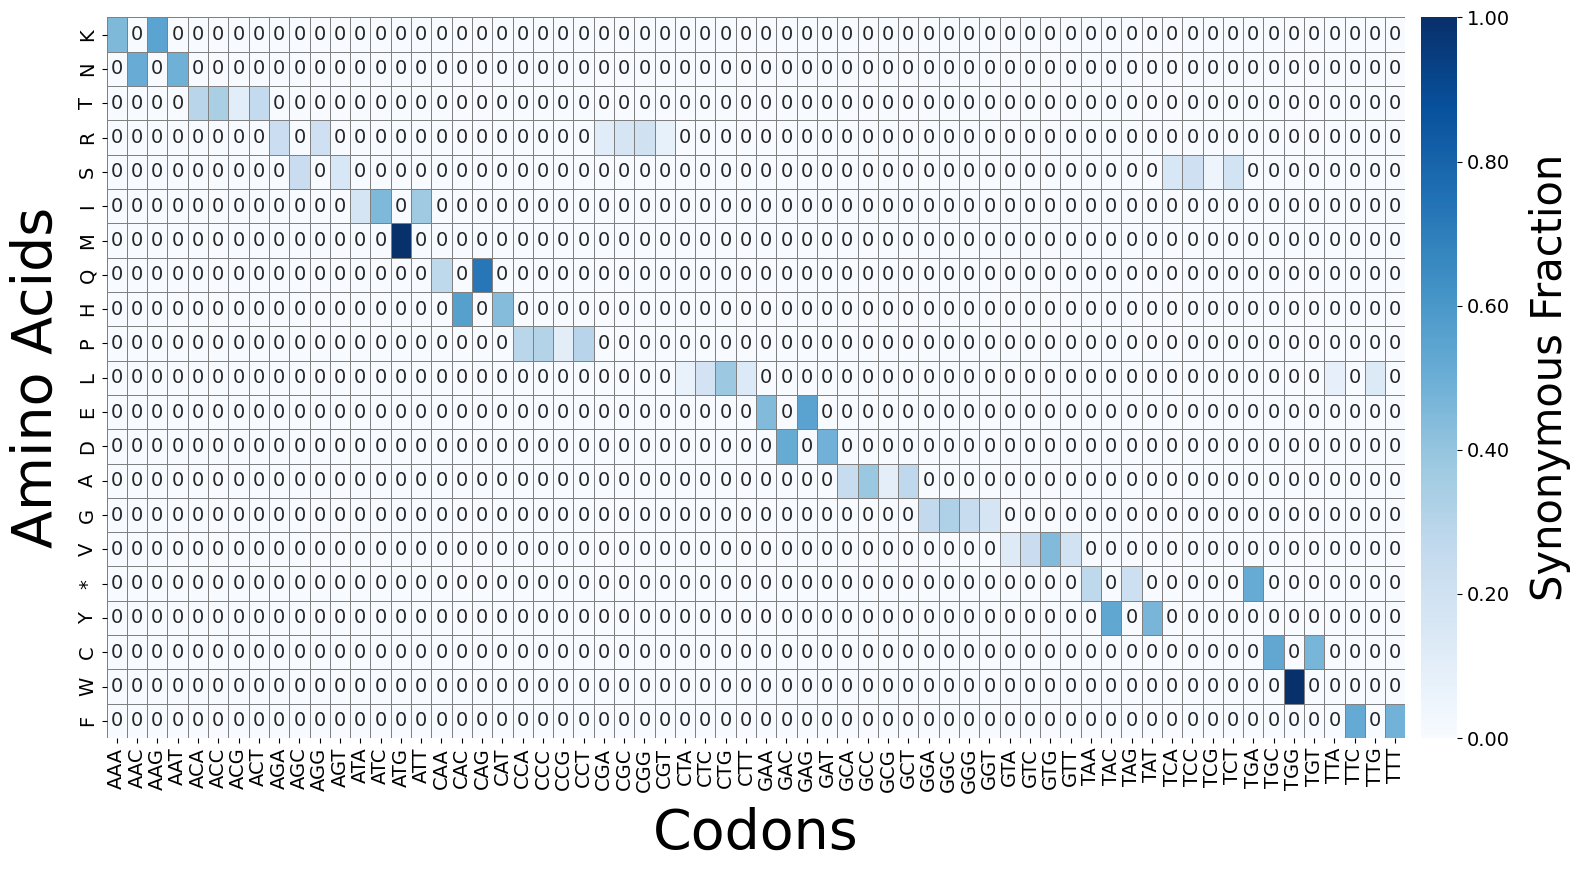

In [39]:
# harmonizer_model._amino_acid_codon_frac_dict

# For each amino acid, list of all possible codons and their relevant fractions (0 if not present)
all_codons = get_dna_codons()

# Initialize a dictionary with all possible codons for each amino acid
amino_acid_codon_frac_dict_full = {aa: [0] * len(all_codons) for aa in harmonizer_model._amino_acid_codon_frac_dict.keys()}

# Fill in the fractions for the codons that are present
for aa, codons in harmonizer_model._amino_acid_codon_frac_dict.items():
    for codon, frac in zip(harmonizer_model._amino_acid_codon_dict[aa], codons):
        index = all_codons.index(codon)
        amino_acid_codon_frac_dict_full[aa][index] = frac

amino_acid_codon_frac_dict_full

plt.figure(figsize=(16, 8))

# Custom annotation function to label only tiles with exactly 0 value
def annot_func(data):
    return data.map(lambda v: '0' if v == 0 else '')

htmap = sns.heatmap(pd.DataFrame(amino_acid_codon_frac_dict_full).T, cmap='Blues', linewidths=0.5, linecolor='grey', annot=annot_func(pd.DataFrame(amino_acid_codon_frac_dict_full).T), fmt='', cbar=True, xticklabels=all_codons,
                    cbar_kws={"orientation": "vertical", 'shrink': 1, 'pad': 0.01, 'format': '%.2f'}, annot_kws={"size": 14})

# Update cbar title and tick labels font size
cbar = htmap.collections[0].colorbar
cbar.ax.tick_params(labelsize=14)
cbar.set_label('Synonymous Fraction', fontsize=30, labelpad=14)
htmap.figure.tight_layout()
# plt.title("Codon Probability Heatmap")
plt.xlabel("Codons", fontsize=40, labelpad=10)
plt.ylabel("Amino Acids", fontsize=40, labelpad=10)
plt.tick_params(axis='both', labelsize=14)

# save as svg
plt.savefig("codon_probability_heatmap.svg", format='svg', bbox_inches='tight')

plt.show()

In [13]:
# Create a dictionary mapping each codon to a single frequency
codon_to_fraction = {}
for aa, freqs in harmonizer_model._amino_acid_codon_frac_dict.items():
    for codon, freq in zip(harmonizer_model._amino_acid_codon_dict[aa], freqs):
        codon_to_fraction[codon] = freq

# Save with numpy to a file
np.save(os.path.join(data_path, "codon_to_fraction.npy"), codon_to_fraction)

In [14]:
test_nt_seq = test_df['seq']
test_aa_seq = test_df['amino_acid_seq']

pred = harmonizer_model.predict_codons(test_aa_seq, verbose=True)
accuracies = harmonizer_model.calculate_accuracies(pred, test_nt_seq, verbose=True)
np.mean(accuracies)

Predicting codons for amino acid sequences...


np.float64(0.44995808273742005)

In [203]:
# save test_df predictions and accuracies columns as pickle
print("Saving predictions and accuracies...")
pd.DataFrame({'mfc_prediction':pred, 
              'mfc_accuracy':accuracies}).to_pickle(os.path.join(data_path, "2_50_mfc.pkl"))

Saving predictions and accuracies...


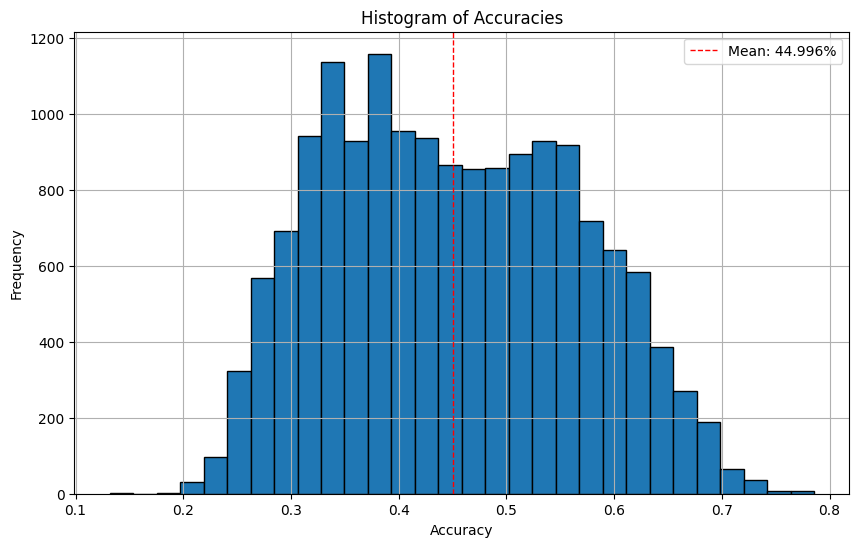

In [202]:
mean_accuracy = np.mean(accuracies)

plt.figure(figsize=(10, 6))
plt.hist(accuracies, bins=30, edgecolor='black')
plt.axvline(mean_accuracy, color='red', linestyle='dashed', linewidth=1, label=f'Mean: {mean_accuracy * 100:.3f}%')

plt.title('Histogram of Accuracies')
plt.xlabel('Accuracy')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()

## Bi-codon Harmonizer

### Bi-Codon Harmonizer Class

In [114]:
class BiCodonHarmonizer:

    def __init__(self, train_X, train_Y, verbose=False):
        """Get aa sequences X and codon sequences Y pandas columns.

        Create Frequency Based Model for bi-codons."""
        self.train_X = train_X
        self.train_Y = train_Y

        if verbose:
            print("--- Training Bi-Codon Frequency Model ---")

        # Create a DataFrame from the nucleotide and amino acid sequences
        self.train_df = pd.DataFrame({'amino_acids': train_X, 'nucleotides': train_Y})
        
        if verbose:
            print("    * Extracting codons...")

        # Extract codons and corresponding amino acids
        self.train_df['codons'] = self.train_df['nucleotides'].str.extractall(r'(.{3})').groupby(level=0).agg(list)
        self.train_df['amino_acids'] = self.train_df['amino_acids'].apply(list)

        if verbose:
            print("    * Creating bi-codon pairs...")

        # Create bi-codon pairs
        self.train_df['bi_codons'] = self.train_df['codons'].apply(lambda x: [x[i] + " " + x[i+1] for i in range(len(x)-1)])
        self.train_df['bi_amino_acids'] = self.train_df['amino_acids'].apply(lambda x: [x[i] + " " + x[i+1] for i in range(len(x)-1)])

        if verbose:
            print("    * Calculating Frequencies...")

        # Initialize dictionaries for bi-codon frequencies and probabilities
        self.bi_codon_freq = {}
        self.bi_codon_prob = {}

        # Count the frequency of each bi-codon for each bi-amino acid
        for bi_aa, bi_codon in zip(self.train_df['bi_amino_acids'].explode(), self.train_df['bi_codons'].explode()):
            if bi_aa not in self.bi_codon_freq:
                self.bi_codon_freq[bi_aa] = {}
            if bi_codon not in self.bi_codon_freq[bi_aa]:
                self.bi_codon_freq[bi_aa][bi_codon] = 0
            self.bi_codon_freq[bi_aa][bi_codon] += 1

        # Normalize the frequencies to get probabilities
        for bi_aa, codon_dict in self.bi_codon_freq.items():
            total_count = sum(codon_dict.values())
            self.bi_codon_prob[bi_aa] = {codon: count / total_count for codon, count in codon_dict.items()}

        if verbose:
            print("--- Training Finished! ---")

    def predict_codons(self, amino_acid_sequences, verbose=False):
        """Predict the codon sequences for a pandas column of amino acid sequences."""
        
        if verbose:
            print("Predicting codons for amino acid sequences...")

        def predict_sequence(seq):
            predicted_codons = ['ATG']  # Start codon
            bi_aa_pairs = [seq[i-1] + " " + seq[i] for i in range(1, len(seq))]
            
            for bi_aa in bi_aa_pairs:
                prev_codon = predicted_codons[-1]
                bi_codon_candidates = {k: v for k, v in self.bi_codon_prob.get(bi_aa, {}).items() if k.startswith(prev_codon)}
                if bi_codon_candidates:
                    bi_codon = max(bi_codon_candidates, key=bi_codon_candidates.get)
                    predicted_codons.append(bi_codon.split(" ")[1])
                else:
                    predicted_codons.append('NNN')  # Default to 'NNN' if no suitable bi-codon is found
            
            return ''.join(predicted_codons)
        
        predicted_codons = amino_acid_sequences.apply(predict_sequence)
        return predicted_codons.tolist()

    def calculate_accuracies(self, predictions, ground_truth, verbose=False):
        """Get model list of predictions and ground truth and return average accuracy"""

        if verbose:
            print("Calculating accuracy...")

        accuracies = []
        for pred, gt in zip(predictions, ground_truth):
            correct = sum([1 for p, g in zip([pred[i:i+3] for i in range(0, len(pred), 3)], [gt[i:i+3] for i in range(0, len(gt), 3)]) if p == g])
            assert len(gt) % 3 == 0
            total = len(gt) // 3
            accuracies.append(correct / total)
        return accuracies

### Train and Test Bi-Codon Harmonizer

In [120]:
# training inputs
nt_sequences = train_df['seq']
aa_sequences = train_df['amino_acid_seq']

# train bi-codon model
bi_codon_harmonizer_model = BiCodonHarmonizer(aa_sequences, nt_sequences, verbose=True)

--- Training Bi-Codon Frequency Model ---
    * Extracting codons...
    * Creating bi-codon pairs...
    * Calculating Frequencies...
--- Training Finished! ---


In [ ]:
# Test bi-codon model
test_nt_seq = test_df['seq']
test_aa_seq = test_df['amino_acid_seq']

bi_codon_pred = bi_codon_harmonizer_model.predict_codons(test_aa_seq, verbose=True)
bi_codon_accuracy = bi_codon_harmonizer_model.calculate_accuracies(bi_codon_pred, test_nt_seq, verbose=True)

print(f"Bi-Codon Harmonizer Accuracy: {np.mean(bi_codon_accuracy)}")

Predicting codons for amino acid sequences...
Bi-Codon Harmonizer Accuracy: 0.4483722398510099


In [197]:
# save test_df predictions and accuracies columns as pickle
print("Saving predictions and accuracies...")
pd.DataFrame({'mfb_prediction':bi_codon_pred, 
              'mfb_accuracy':bi_codon_accuracy}).to_pickle(os.path.join(data_path, "2_50_mfb.pkl"))

Saving predictions and accuracies...


In [199]:
mean_accuracy

np.float64(0.44995808273742005)

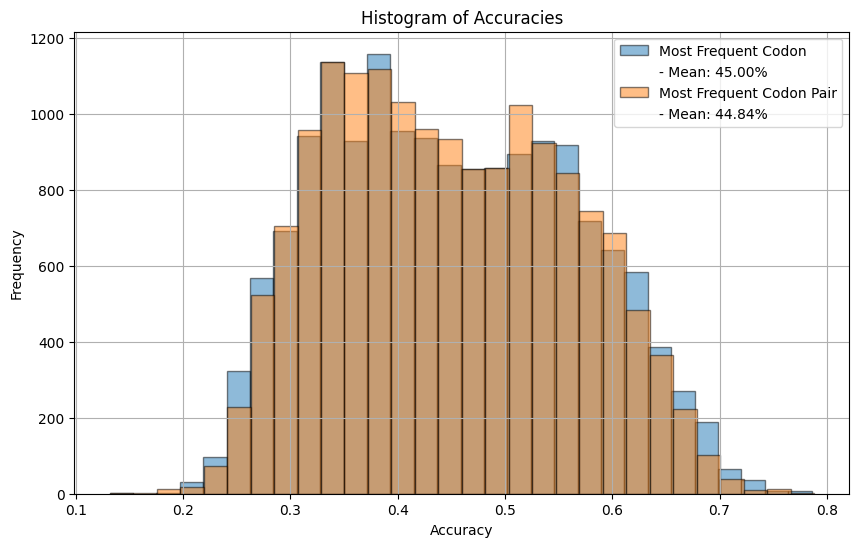

In [198]:
mean_accuracy = np.mean(accuracies)
mean_bi_codon_accuracy = np.mean(bi_codon_accuracy)

plt.figure(figsize=(10, 6))

# Plot histogram for accuracies
plt.hist(accuracies, bins=30, edgecolor='black', alpha=0.5, label='Most Frequent Codon')

plt.axvline(mean_accuracy, color='blue', linestyle='dashed', linewidth=1, label=f'- Mean: {mean_accuracy * 100 :.2f}%', alpha=0)


# Plot histogram for bi_codon_accuracy
plt.hist(bi_codon_accuracy, bins=30, edgecolor='black', alpha=0.5, label='Most Frequent Codon Pair')

plt.axvline(mean_bi_codon_accuracy, color='blue', linestyle='dashed', linewidth=1, label=f'- Mean: {mean_bi_codon_accuracy * 100 :.2f}%', alpha=0)

plt.title('Histogram of Accuracies')
plt.xlabel('Accuracy')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()

## Expression adjusted harmonizer
Not enough training data to separate each unique expression vector - instead we train a harmonizer that accounts for each tissue-specific expression value (for each tissue and for each expression percentile.).

In [268]:
class Expression_Adjusted_Harmonizer:

    def __init__(self, train_df, verbose=False):
        """Get aa sequences X and codon sequences Y pandas columns.

        Create Frequency Based Model."""
        self.train_df = train_df

        self.labels = ['expr_low25', 'expr_pre25_50', 'expr_pre50_75', 'expr_pre75_90', 'expr_top10']
        self.tissues = ['Adipose_Subcutaneous', 'Adipose_Visceral_Omentum', 'Adrenal_Gland', 'Artery_Aorta', 
                   'Artery_Coronary', 'Artery_Tibial', 'Bladder', 'Brain_Amygdala', 'Brain_Anterior_cingulate_cortex_BA24', 
                   'Brain_Caudate_basal_ganglia', 'Brain_Cerebellar_Hemisphere', 'Brain_Cerebellum', 'Brain_Cortex', 'Brain_Frontal_Cortex_BA9', 
                   'Brain_Hippocampus', 'Brain_Hypothalamus', 'Brain_Nucleus_accumbens_basal_ganglia', 'Brain_Putamen_basal_ganglia', 
                   'Brain_Spinal_cord_cervical_c-1', 'Brain_Substantia_nigra', 'Breast_Mammary_Tissue', 'Cells_EBV-transformed_lymphocytes', 
                   'Cells_Cultured_fibroblasts', 'Cervix_Ectocervix', 'Cervix_Endocervix', 'Colon_Sigmoid', 'Colon_Transverse', 'Esophagus_Gastroesophageal_Junction', 
                   'Esophagus_Mucosa', 'Esophagus_Muscularis', 'Fallopian_Tube', 'Heart_Atrial_Appendage', 'Heart_Left_Ventricle', 'Kidney_Cortex', 
                   'Kidney_Medulla', 'Liver', 'Lung', 'Minor_Salivary_Gland', 'Muscle_Skeletal', 'Nerve_Tibial', 'Ovary', 'Pancreas', 'Pituitary', 
                   'Prostate', 'Skin_Not_Sun_Exposed_Suprapubic', 'Skin_Sun_Exposed_Lower_leg', 'Small_Intestine_Terminal_Ileum', 'Spleen', 'Stomach', 
                   'Testis', 'Thyroid', 'Uterus', 'Vagina', 'Whole_Blood']
        

        self._amino_acid_codon_dict = get_amino_acid_codon_dict()

        if verbose:
            print("--- Training Model ---")
        
        # Vanilla Harmonizer trained on all of the training data
        train_X = train_df['amino_acid_seq']
        train_Y = train_df['seq']
        if verbose:
            print(" Training vanilla harmonizer:")
        self.vanilla_harmonizer = Harmonizer(train_X, train_Y, verbose=verbose)
        
        # Tissue-expression harmonizers trained on data such that tissue 'A' has expression 'B'
        if verbose:
            print(" Training tissue-expression harmonizers::")
        self.exp_harmonizers = []
        for i, tissue in enumerate(self.tissues):
            if verbose:
                print(f"  + Tissue = {tissue}: ")
            self.exp_harmonizers.append([])
            for expression in self.labels:
                if verbose:
                    print(f"    * Training {tissue} : {expression} harmonizer...")
                
                tissue_expression_subset = train_df[train_df['median'].apply(lambda x: x[i] if isinstance(x, tuple) else None) == expression]
                train_X = tissue_expression_subset['amino_acid_seq']
                train_Y = tissue_expression_subset['seq']

                tissue_expression_model = Harmonizer(train_X, train_Y)

                self.exp_harmonizers[-1].append(tissue_expression_model)


    def average_softmax_dicts(self, dict_list):
        """Average and softmax a list of dictionaries with the same keys 
        and same length list-values for a key."""
        
        def softmax(x):
            e_x = np.exp(x - np.max(x))
            return e_x / e_x.sum(axis=0)

        keys = dict_list[0].keys()
        averaged_dict = {key: np.mean([d[key] for d in dict_list], axis=0) for key in keys}
        return {key: softmax(values) for key, values in averaged_dict.items()}
    

    def calculate_amino_acid_most_freq_codon_dict(self, harmonizer_list):
        """Create a dictionary mapping amino acids to most frequent codon"""
        amino_acid_most_freq_codon_dict = {}

        dict_list = [harmonizer._amino_acid_codon_frac_dict for harmonizer in harmonizer_list]
        averaged_dict = self.average_softmax_dicts(dict_list)

        for aa, codon_fracs in averaged_dict.items():
            most_freq_index = np.argmax(codon_fracs)
            amino_acid_most_freq_codon_dict[aa] = self._amino_acid_codon_dict[aa][most_freq_index]

        return amino_acid_most_freq_codon_dict


    def predict_codons(self, amino_acids_expression_df, verbose=False):
        """Predict the codon sequences for a pandas dataframe 
        with a column 'amino_acid_seq' of amino acid sequences and a column 'median' of expression.
        
        By averaging the tissue-expression models' probabilities + softmax-ing"""
        
        if verbose:
            print("Predicting codons for amino acid sequences...")

        def predict_sequence(row):
            # Check if 'median' value is NaN
            if row[['median']].isna().any():
                return self.vanilla_harmonizer.predict_codons(pd.Series([row['amino_acid_seq']]))[0]
            
            # Get the indices for tissues and expressions
            tissue_indices = range(len(row['median']))
            expression_indices = [self.labels.index(expression) for expression in row['median']]
            
            # Predict codons for each tissue and expression combination
            harmonizer_list = [
            self.exp_harmonizers[tissue_idx][expression_idx] 
            for tissue_idx, expression_idx in zip(tissue_indices, expression_indices)
            ]
            
            # Average the probabilities and softmax
            averaged_most_freq_dict = self.calculate_amino_acid_most_freq_codon_dict(harmonizer_list)

            return ''.join(averaged_most_freq_dict[aa] for aa in row["amino_acid_seq"])
        
        predictions = amino_acids_expression_df.apply(predict_sequence, axis=1)
        return predictions
       
    def calculate_accuracies(self, predictions, ground_truth, verbose=False):
        """Get model list of predictions and ground truth and return average accuracy"""

        if verbose:
            print("Calculating accuracy...")

        accuracies = []
        for pred, gt in zip(predictions, ground_truth):
            correct = sum([1 for p, g in zip([pred[i:i+3] for i in range(0, len(pred), 3)], [gt[i:i+3] for i in range(0, len(gt), 3)]) if p == g])
            assert len(gt) % 3 == 0
            total = len(gt) // 3
            accuracies.append(correct / total)
        return accuracies

In [269]:
small_train_sample = train_df.head(1000)

exp_model = Expression_Adjusted_Harmonizer(small_train_sample, verbose=True)

--- Training Model ---
 Training vanilla harmonizer:
--- Training Frequency Model ---
    * Calculating Codon Fractions...
    * Finding Most Frequent Codon for each Amino Acid...
--- Training Finished! ---
 Training tissue-expression harmonizers::
  + Tissue = Adipose_Subcutaneous: 
    * Training Adipose_Subcutaneous : expr_low25 harmonizer...
    * Training Adipose_Subcutaneous : expr_pre25_50 harmonizer...
    * Training Adipose_Subcutaneous : expr_pre50_75 harmonizer...
    * Training Adipose_Subcutaneous : expr_pre75_90 harmonizer...
    * Training Adipose_Subcutaneous : expr_top10 harmonizer...
  + Tissue = Adipose_Visceral_Omentum: 
    * Training Adipose_Visceral_Omentum : expr_low25 harmonizer...
    * Training Adipose_Visceral_Omentum : expr_pre25_50 harmonizer...
    * Training Adipose_Visceral_Omentum : expr_pre50_75 harmonizer...
    * Training Adipose_Visceral_Omentum : expr_pre75_90 harmonizer...
    * Training Adipose_Visceral_Omentum : expr_top10 harmonizer...
  + Tis

In [240]:
small_test_sample = test_df.sample(1000)

exp_harmonized_predictions = exp_model.predict_codons(small_test_sample, verbose=True)

Predicting codons for amino acid sequences...


In [241]:
np.mean(exp_model.calculate_accuracies(exp_harmonized_predictions, small_test_sample['seq'], verbose=True))

Calculating accuracy...


np.float64(0.4508543583692519)

**Compare to vanilla harmonizer:**

In [242]:
mfc_model = Harmonizer(small_train_sample['amino_acid_seq'], small_train_sample['seq'], verbose=True)

--- Training Frequency Model ---
    * Calculating Codon Fractions...
    * Finding Most Frequent Codon for each Amino Acid...
--- Training Finished! ---


In [243]:
harmonized_predictions = mfc_model.predict_codons(small_test_sample['amino_acid_seq'], verbose=True)
np.mean(mfc_model.calculate_accuracies(mfc_model.predict_codons(small_test_sample['amino_acid_seq']), small_test_sample['seq'], verbose=True))

Predicting codons for amino acid sequences...


np.float64(0.4502082592745073)

# Harmonizer Trained on Specific Tissue-Expression

In [124]:
tissue_idx = 15

# Example inputs for training
tissue_exp_train_df = train_df[train_df['median'].apply(lambda x: x[tissue_idx] if isinstance(x, list) else None) == 'expr_top10']
tissue_exp_nt_sequences = tissue_exp_train_df['seq']
tissue_exp_aa_sequences = tissue_exp_train_df['amino_acid_seq']

# Create an instance of Frequency_Model
harmonizer_model = Harmonizer(tissue_exp_aa_sequences, tissue_exp_nt_sequences, verbose=True)


--- Training Frequency Model ---
    * Calculating Codon Fractions...
    * Finding Most Frequent Codon for each Amino Acid...
--- Training Finished! ---


In [125]:
tissue_exp_predictions = harmonizer_model.predict_codons(test_df['amino_acid_seq'], verbose=True)
tissue_exp_accuracies = harmonizer_model.calculate_accuracies(tissue_exp_predictions, test_df['seq'], verbose=True)

# append predictions and accuracies to test_df
test_df['tissue_exp_prediction'] = tissue_exp_predictions
test_df['tissue_exp_accuracy'] = tissue_exp_accuracies
test_df['mfc_accuracy'] = accuracies

print(np.mean(tissue_exp_accuracies))
print(np.mean(accuracies))

Predicting codons for amino acid sequences...
0.4478749353256393
0.44995808273742005


In [126]:
# sort by sequence median float
sorted_df = test_df.copy()
sorted_df['median_float'] = sorted_df['median_float'].apply(lambda x: x[tissue_idx] if isinstance(x, tuple) else -1)
sorted_df = sorted_df.sort_values(by='median_float')

sequence_exp = sorted_df['median_float']

# group by sequence lengths and calculate the average of the accuracy columns
grouped = sorted_df.groupby(sequence_exp)
average_accuracies_per_exp = grouped[['tissue_exp_accuracy', 'mfc_accuracy']].mean()

average_accuracies_per_exp

,tissue_exp_accuracy,mfc_accuracy
median_float,,
-1.000000,0.421470,0.425456
0.000000,0.449160,0.452735
0.005000,0.431135,0.438813
0.010000,0.407683,0.414067
0.015000,0.417640,0.419864
...,...,...
588.140015,0.481818,0.463636
697.924988,0.416149,0.422360
710.410034,0.726415,0.694969


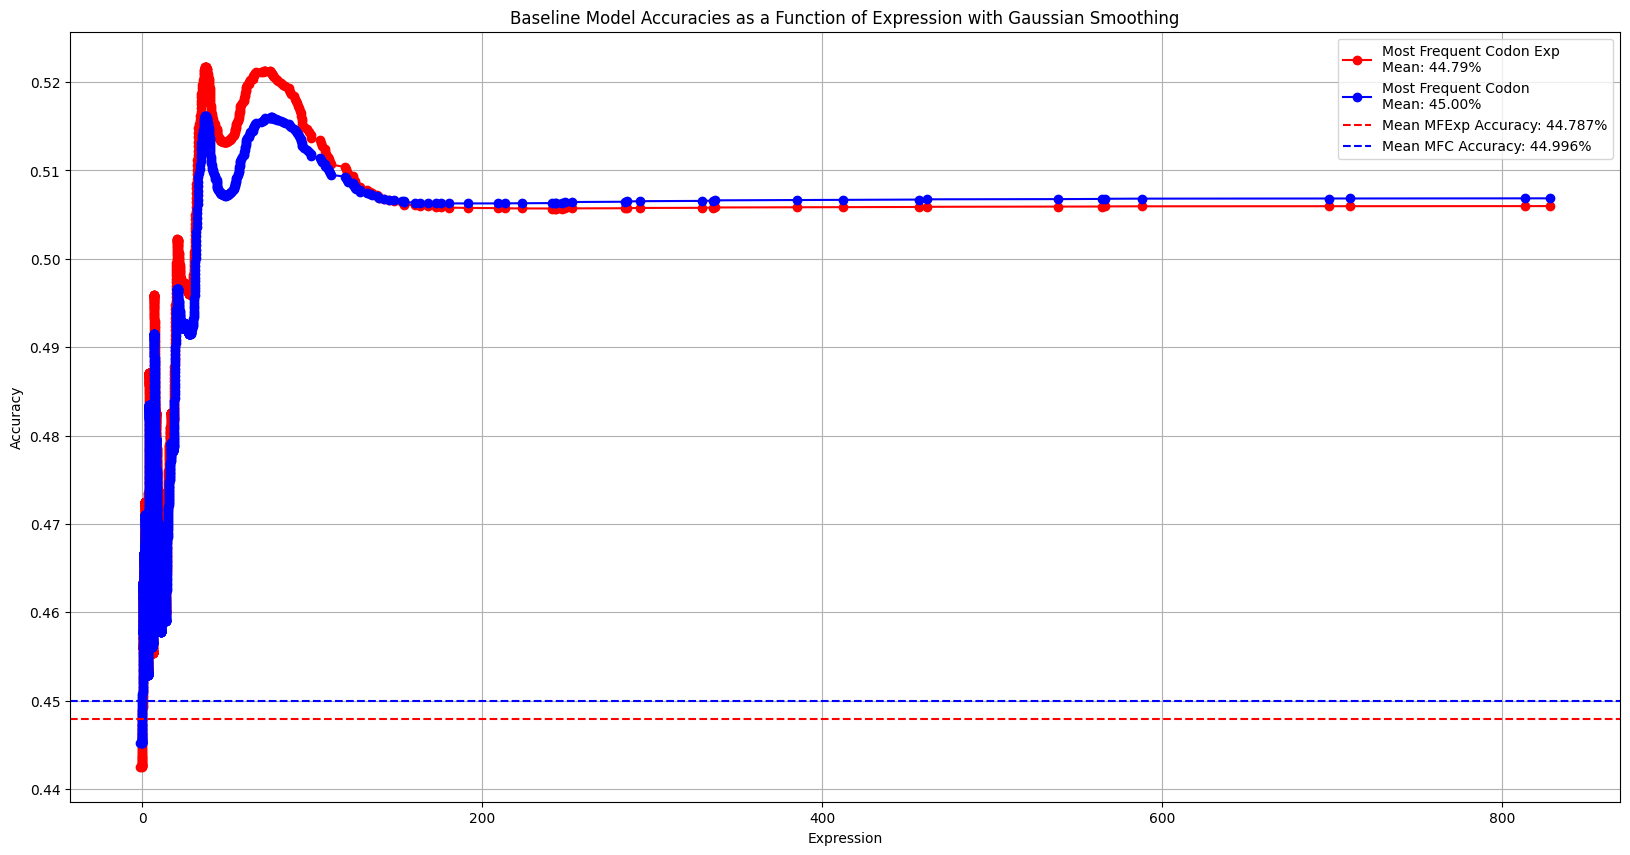

In [127]:
from scipy.ndimage import gaussian_filter1d

sgma = 30

# Apply Gaussian smoothing
smoothed_mfexp_accuracy = gaussian_filter1d(average_accuracies_per_exp['tissue_exp_accuracy'], sigma=sgma)
smoothed_mfc_accuracy = gaussian_filter1d(average_accuracies_per_exp['mfc_accuracy'], sigma=sgma)


avg_mfexp_accuracy = np.mean(test_df['tissue_exp_accuracy'])
avg_mfc_accuracy = np.mean(test_df['mfc_accuracy'])


plt.figure(figsize=(20, 10))

plt.plot(average_accuracies_per_exp.index, smoothed_mfexp_accuracy, color='r', marker='o', alpha=1, label=f'Most Frequent Codon Exp\nMean: {avg_mfexp_accuracy * 100 :.2f}%')
plt.plot(average_accuracies_per_exp.index, smoothed_mfc_accuracy, color='b', marker='o', alpha=1, label=f'Most Frequent Codon\nMean: {avg_mfc_accuracy * 100 :.2f}%')

# plot horizontal lines for the average accuracies
plt.axhline(avg_mfexp_accuracy, color='r', linestyle='--', label=f'Mean MFExp Accuracy: {avg_mfexp_accuracy * 100 :.3f}%')
plt.axhline(avg_mfc_accuracy, color='b', linestyle='--', label=f'Mean MFC Accuracy: {avg_mfc_accuracy * 100 :.3f}%')

plt.title('Baseline Model Accuracies as a Function of Expression with Gaussian Smoothing')
plt.xlabel('Expression')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [128]:
average_accuracies_per_exp

,tissue_exp_accuracy,mfc_accuracy
median_float,,
-1.000000,0.421470,0.425456
0.000000,0.449160,0.452735
0.005000,0.431135,0.438813
0.010000,0.407683,0.414067
0.015000,0.417640,0.419864
...,...,...
588.140015,0.481818,0.463636
697.924988,0.416149,0.422360
710.410034,0.726415,0.694969


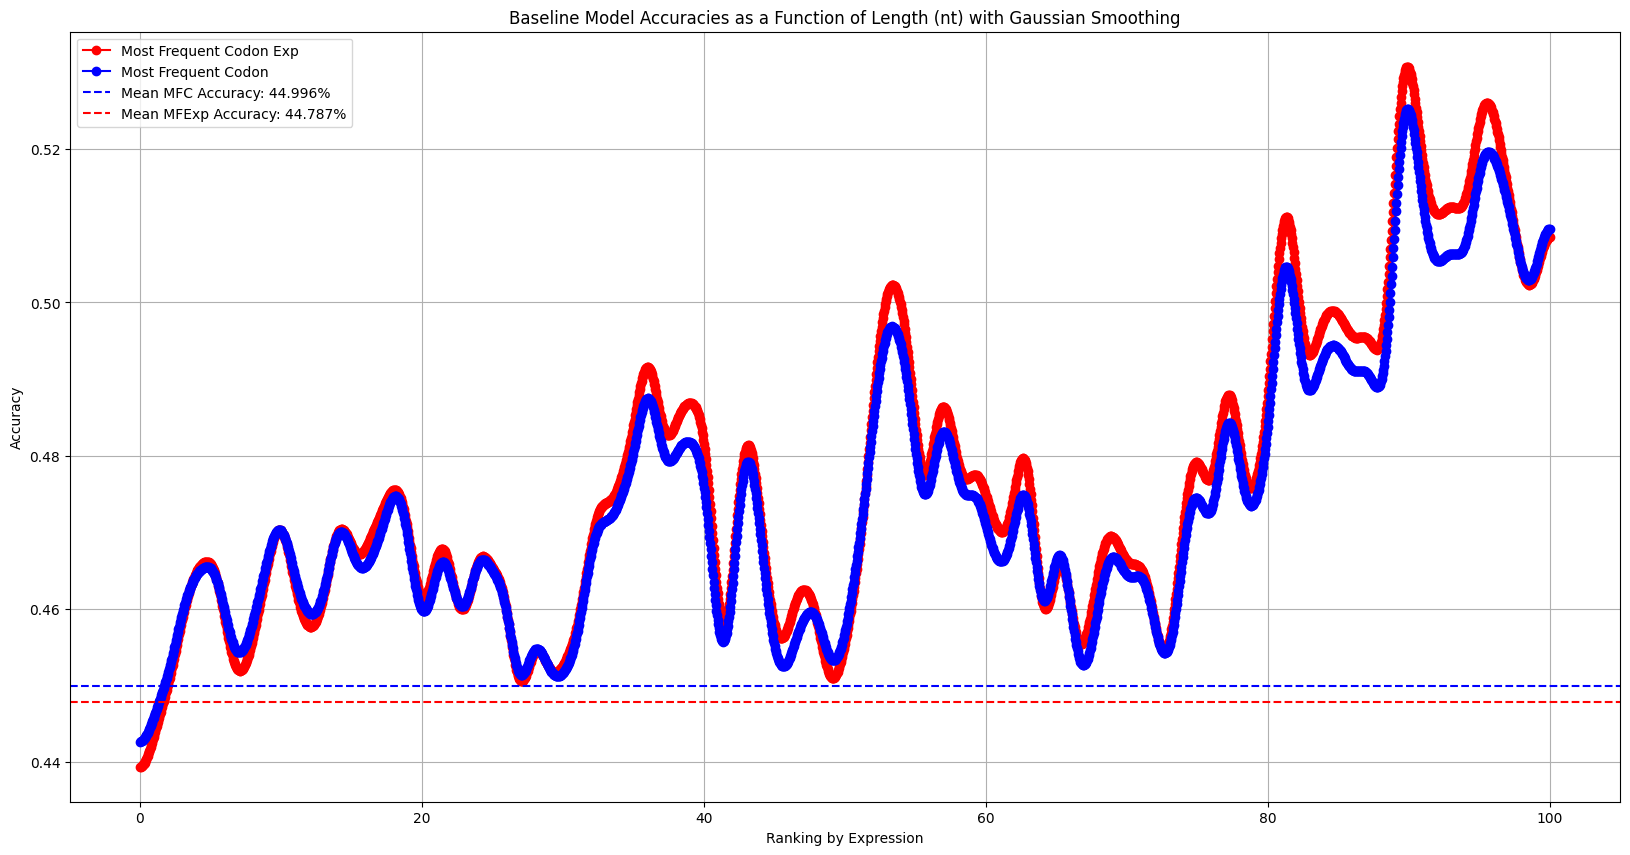

In [ ]:
# Rank sequence lengths by percentages
ranked_exps = pd.Series(average_accuracies_per_exp.index).rank(pct=True)
ranked_exps = ranked_exps * 100

sgma = 20

# Apply Gaussian smoothing
smoothed_mfexp_accuracy = gaussian_filter1d(average_accuracies_per_exp['tissue_exp_accuracy'], sigma=sgma)
smoothed_mfc_accuracy = gaussian_filter1d(average_accuracies_per_exp['mfc_accuracy'], sigma=sgma)

plt.figure(figsize=(20, 10))

plt.plot(ranked_exps, smoothed_mfexp_accuracy, marker='o', alpha=1, color='r', label='Most Frequent Codon Exp')
plt.plot(ranked_exps, smoothed_mfc_accuracy, marker='o', alpha=1, color='b', label='Most Frequent Codon')


# plot horizontal lines for the average accuracies
plt.axhline(avg_mfc_accuracy, color='b', linestyle='--', label=f'Mean MFC Accuracy: {avg_mfc_accuracy * 100 :.3f}%')
plt.axhline(avg_mfexp_accuracy, color='r', linestyle='--', label=f'Mean MFExp Accuracy: {avg_mfexp_accuracy * 100 :.3f}%')


plt.title('Baseline Model Accuracies as a Function of Length (nt) with Gaussian Smoothing')
plt.xlabel('Ranking by Expression')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

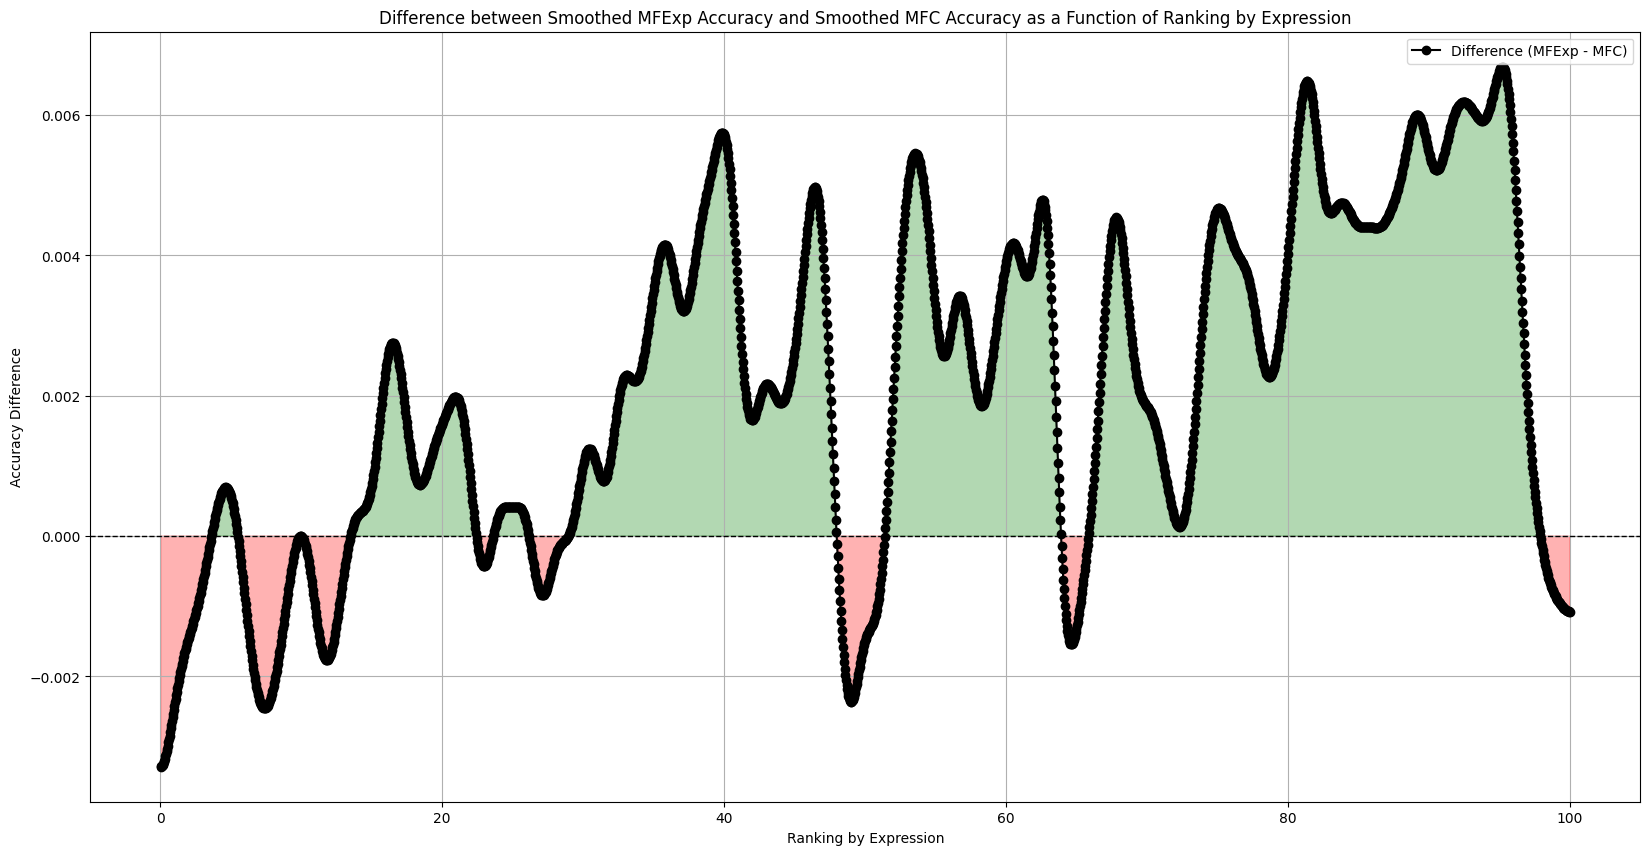

In [ ]:
# Calculate the difference between smoothed accuracies
accuracy_difference = smoothed_mfexp_accuracy - smoothed_mfc_accuracy

plt.figure(figsize=(20, 10))

# Plot the difference
plt.plot(ranked_exps, accuracy_difference, marker='o', alpha=1, color='black', label='Difference (MFExp - MFC)')

# Fill the area below the curve with red for negative values and green for positive values
plt.fill_between(ranked_exps, accuracy_difference, where=(accuracy_difference >= 0), interpolate=True, color='green', alpha=0.3)
plt.fill_between(ranked_exps, accuracy_difference, where=(accuracy_difference < 0), interpolate=True, color='red', alpha=0.3)

# Plot horizontal line at y=0 for reference
plt.axhline(0, color='black', linestyle='--', linewidth=1)

plt.title('Difference between Smoothed MFExp Accuracy and Smoothed MFC Accuracy as a Function of Ranking by Expression')
plt.xlabel('Ranking by Expression')
plt.ylabel('Accuracy Difference')
plt.legend()
plt.grid(True)
plt.show()